In [1]:
from HODDIES.sim_loader import AbacusSummitSim
from HODDIES import HOD # from sim_loader import setup_logging
import numpy as np
import matplotlib.pyplot as plt
# setup_logging()
default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/dvs_ro/cfs/cdirs/desi/cosmosim/Abacus',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
}
test=AbacusSummitSim(setup_logger=True, **default_abacus_param)

HOD_obj = HOD(base_catalog=test, tracers='LRG', setup_logger=True)


[000000.00]  08-14 00:55 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[000000.02]  08-14 00:55 AbacusSummitSim              INFO     Load Compaso catalogue from /dvs_ro/cfs/cdirs/desi/cosmosim/Abacus/small/AbacusSummit_small_c000_ph3000/halos/z0.500 with particles...
[000003.99]  08-14 00:55 AbacusSummitSim              INFO     Done took 00:00:03
[000004.01]  08-14 00:55 AbacusSummitSim              INFO     Compute required columns...
[000004.12]  08-14 00:55 AbacusSummitSim              INFO     Done took 00:00:00
setup_logger True
[000004.14]  08-14 00:55 HOD                          INFO     Initializing HOD.
[000004.15]  08-14 00:55 HOD                          INFO     Set number of threads to 32
[000005.57]  08-14 00:55 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology


In [36]:

HOD_obj.args['clustering_settings']['delta_sigma']['edges_rp'] = np.geomspace(0.01, 100, 30)
HOD_obj.args['clustering_settings']['delta_sigma']['pimax']  = HOD_obj.boxsize/2 #
cat = HOD_obj.make_mock_cat(fix_seed=1)

[000243.18]  08-14 00:59 HOD                          INFO     Create mock catalog for ['LRG']
[000243.20]  08-14 00:59 HOD                          INFO     Run HOD for LRG
[000243.31]  08-14 00:59 HOD                          INFO     LRG mock catalogue done in 0.11 sec
[000243.32]  08-14 00:59 HOD                          INFO     Total time to create the mock catalog: 0.14 seconds
[000243.32]  08-14 00:59 HOD                          INFO     Total number of LRG: 86898 with 65047 central, 21851 satellite and a satellites fraction: 0.25
[000243.32]  08-14 00:59 HOD                          INFO     Total number of galaxies in the catalog: 86898
[000243.32]  08-14 00:59 HOD                          INFO     Total number of centrals: 65047
[000243.32]  08-14 00:59 HOD                          INFO     Total number of satellites: 21851


[000246.62]  08-14 00:59 HOD                          INFO     Compute ΔΣ for LRG...
[000249.11]  08-14 01:00 HOD                          INFO     Done in 2.497 s


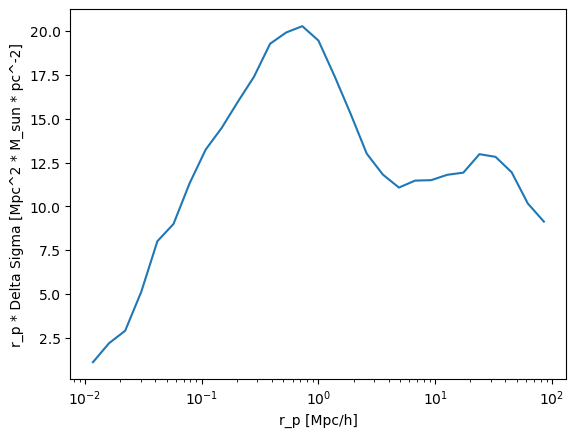

In [37]:
rp_hoddies, ds_hoddies = HOD_obj.get_delta_sigma(cat)
    
plt.plot(rp_hoddies,rp_hoddies*ds_hoddies)
plt.xscale('log')
plt.xlabel('r_p [Mpc/h]')
plt.ylabel('r_p * Delta Sigma [Mpc^2 * M_sun * pc^-2]')
plt.show()

In [38]:
"""
Cross-check DeltaSigma(rp) from halotools against the pycorr-based estimator in HODDIES.

Both codes are given the *same* galaxies, the *same* particles and the *same*
mean matter density, so any residual difference is in the estimator rather than
in the inputs.

Key point: halotools' delta_sigma integrates over the full box along the LOS
(no pimax). To compare like with like, the pycorr call must use
pimax = boxsize / 2, NOT the pimax from your clustering settings.

Units throughout: positions in Mpc/h, rho_m in (Msun/h) / (Mpc/h)^3,
DeltaSigma out in h Msun / pc^2.
"""

import numpy as np
from halotools.mock_observables import mean_delta_sigma as ht_delta_sigma




# --------------------------------------------------------------------------
# halotools estimator
# --------------------------------------------------------------------------
def delta_sigma_halotools(gal_pos, part_pos, boxsize, rp_edges, rho_m,
                          nthreads=64):
    """
    DeltaSigma(rp) from halotools.mock_observables.delta_sigma.

    The particle mass is defined so that the particles carry the full box mass:
    m_eff = rho_m * boxsize^3 / N_particles. With that convention the
    downsampling factor is 1 by construction, whatever subsample was passed in.
    """
    m_eff = rho_m * boxsize**3 / len(part_pos)

    ds = ht_delta_sigma(
        gal_pos, part_pos,
        effective_particle_masses=m_eff,
        rp_bins=rp_edges,
        period=boxsize,
        num_threads=nthreads)

    return ds *1e-12 


# --------------------------------------------------------------------------
# Driver
# --------------------------------------------------------------------------

import matplotlib.pyplot as plt

boxsize = HOD_obj.boxsize                                  
rho_m   = HOD_obj.cosmo.rho_m(0.5) * 1e10                  

gal_pos = np.vstack([cat['x'], cat['y'], cat['z']]).T      
gal_pos = gal_pos % boxsize

part_pos = np.asarray(HOD_obj.part_subsamples['pos'])      
part_pos = part_pos % boxsize

# Same downsampling for both codes, drawn once
downsample = 0.01
if downsample < 1.0:
    rng      = np.random.default_rng(42)
    part_pos = part_pos[rng.random(len(part_pos)) < downsample]

print(f'boxsize   : {boxsize}')
print(f'rho_m     : {rho_m:.4e} (Msun/h)/(Mpc/h)^3')
print(f'galaxies  : {len(gal_pos)}')
print(f'particles : {len(part_pos)}  (after downsampling)')
print(f'n_gal     : {len(gal_pos) / boxsize**3:.4e} (h/Mpc)^3')

rp_edges = HOD_obj.args['clustering_settings']['delta_sigma']['edges_rp']  


ds_ht = delta_sigma_halotools(
    gal_pos, part_pos, boxsize, rp_edges, rho_m) 


boxsize   : 500.0
rho_m     : 8.7475e+10 (Msun/h)/(Mpc/h)^3
galaxies  : 86898
particles : 492261  (after downsampling)
n_gal     : 6.9518e-04 (h/Mpc)^3



     rp        pycorr      halotools     ratio
   0.0117      95.7600      80.1669    1.1945
   0.0161     136.9837     108.2272    1.2657
   0.0221     131.7356     160.8611    0.8189
   0.0304     169.0806     165.9500    1.0189
   0.0418     192.0878     166.6088    1.1529
   0.0574     156.9270     156.3849    1.0035
   0.0788     143.6553     140.0558    1.0257
   0.1083     122.3465     115.3593    1.0606
   0.1487      97.4269      95.9563    1.0153
   0.2043      78.1859      77.6417    1.0070
   0.2807      61.9804      62.6212    0.9898
   0.3857      49.9920      49.4786    1.0104
   0.5298      37.6032      37.7267    0.9967
   0.7279      27.8636      27.2911    1.0210
   1.0000      19.4631      19.0942    1.0193
   1.3738      12.6947      12.5469    1.0118
   1.8874       8.0970       7.9342    1.0205
   2.5929       5.0195       4.8825    1.0281
   3.5622       3.3182       3.1933    1.0391
   4.8939       2.2637       2.2202    1.0196
   6.7234       1.7070       1.7

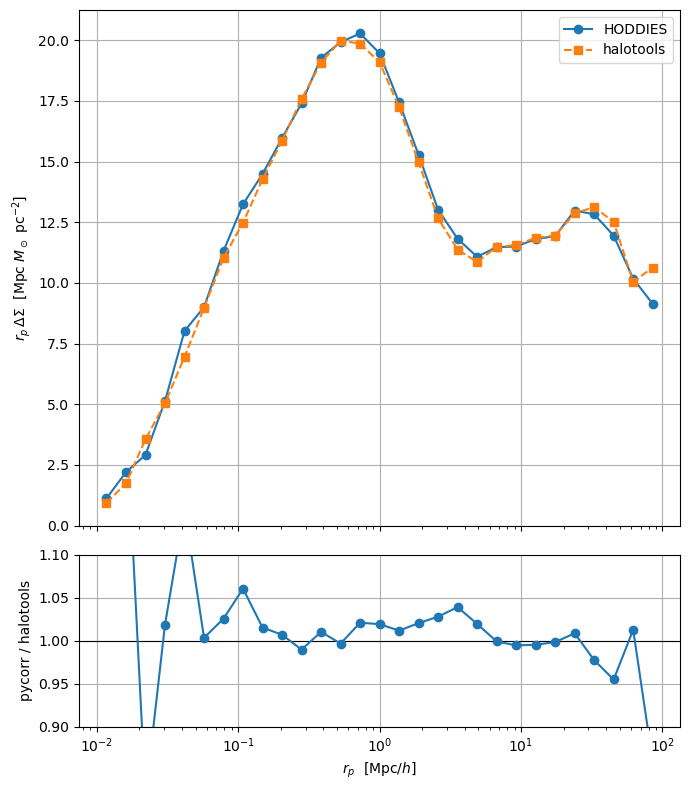

In [40]:


ratio = ds_hoddies / ds_ht
print('\n     rp        pycorr      halotools     ratio')
for a, b, c, d in zip(rp_hoddies, ds_hoddies, ds_ht, ratio):
    print(f'{a:9.4f}  {b:11.4f}  {c:11.4f}  {d:8.4f}')

print(f'\nmedian ratio        : {np.median(ratio):.4f}')
print(f'ratio / h           : {np.median(ratio) / 0.6736:.4f}')
print(f'ratio * h           : {np.median(ratio) * 0.6736:.4f}')



fig, ax = plt.subplots(2, 1, figsize=(7, 8), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1]})

ax[0].plot(rp_hoddies, rp_hoddies * ds_hoddies, 'o-', label='HODDIES')
ax[0].plot(rp_hoddies, rp_hoddies * ds_ht, 's--', label='halotools')
ax[0].set_xscale('log')
ax[0].set_ylabel(r'$r_p\,\Delta\Sigma$  [Mpc $M_\odot$ pc$^{-2}$]')
ax[0].legend()
ax[0].grid()
ax[1].axhline(1., color='k', lw=0.8)
ax[1].plot(rp_hoddies, ratio, 'o-')
ax[1].set_xlabel(r'$r_p$  [Mpc/$h$]')
ax[1].set_ylabel('pycorr / halotools')
ax[1].set_ylim(0.9, 1.1)
ax[1].grid()

plt.tight_layout()
# plt.savefig('delta_sigma_comparison.png', dpi=130)
# print('\nSaved delta_sigma_comparison.png')